In [36]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

In [37]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(199)

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class CubeCylinderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
    
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        cube_path = os.path.join(root_dir, "fCube_Images")
        cylinder_path = os.path.join(root_dir, "fCylinder_Images")
        

        for file in os.listdir(cube_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                self.samples.append(
                    (os.path.join(cube_path, file), 0)
                )
        
        for file in os.listdir(cylinder_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                self.samples.append(
                    (os.path.join(cylinder_path, file), 1)
                )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = CubeCylinderDataset(root_dir=".", transform=transform)

print("Total de imagens:", len(dataset))
img, label = dataset[0]
print("Shape:", img.shape, "Label:", label)

Total de imagens: 2000
Shape: torch.Size([3, 128, 128]) Label: 0


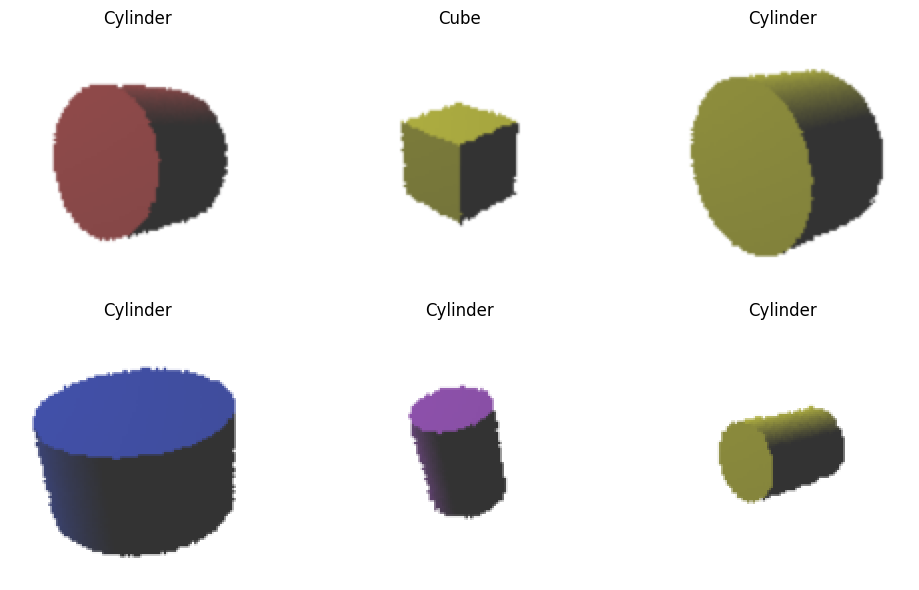

In [18]:
import numpy as np
import matplotlib.pyplot as plt

num_examples = 6
randomlist = np.random.randint(0, len(dataset), size=num_examples)

plt.figure(figsize=(10, 6))

for plot_idx, data_idx in enumerate(randomlist):
    img, label = dataset[data_idx]
    
    img = img.permute(1, 2, 0)
    
    plt.subplot(2, 3, plot_idx + 1)
    plt.imshow(img)
    plt.title("Cube" if label == 0 else "Cylinder")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        # ---------- Encoder ----------
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 128 → 64
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 64 → 32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 32 → 16
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 16 → 8
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)

        # ---------- Decoder ----------
        self.fc_dec = nn.Linear(latent_dim, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 8 → 16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 32 → 64
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 64 → 128
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu, logvar)

        h = self.fc_dec(z)
        h = h.view(x.size(0), 256, 8, 8)

        x_hat = self.decoder(h)

        return x_hat, mu, logvar
    
    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(z.size(0), 256, 8, 8)
        return self.decoder(h)

In [20]:
def vae_loss(x, x_hat, mu, logvar):
    recon = F.mse_loss(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

In [39]:
from torch.utils.data import DataLoader, random_split

dataset_size = len(dataset)


train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 100

for epoch in range(epochs):


    model.train()
    train_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss = vae_loss(x, x_hat, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss = vae_loss(x, x_hat, mu, logvar)
            test_loss += loss.item()

    test_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Test: {test_loss:.4f}")

cpu
Epoch 000 | Train: 4170.8196 | Test: 2207.9021
Epoch 001 | Train: 1711.4524 | Test: 1256.6952
Epoch 002 | Train: 1203.7171 | Test: 1169.1778
Epoch 003 | Train: 1121.7253 | Test: 1023.4138
Epoch 004 | Train: 903.8029 | Test: 840.4045
Epoch 005 | Train: 840.2668 | Test: 789.9699
Epoch 006 | Train: 765.4770 | Test: 708.4319
Epoch 007 | Train: 700.2591 | Test: 644.9868
Epoch 008 | Train: 631.6871 | Test: 581.6654
Epoch 009 | Train: 592.4182 | Test: 543.3328
Epoch 010 | Train: 531.4494 | Test: 455.6951
Epoch 011 | Train: 444.6882 | Test: 392.7427
Epoch 012 | Train: 387.0867 | Test: 366.2605
Epoch 013 | Train: 371.0535 | Test: 340.2812
Epoch 014 | Train: 335.4664 | Test: 313.2871
Epoch 015 | Train: 320.6061 | Test: 312.5747
Epoch 016 | Train: 300.3962 | Test: 282.2046
Epoch 017 | Train: 291.0698 | Test: 273.2296
Epoch 018 | Train: 245.7029 | Test: 236.0950
Epoch 019 | Train: 225.9661 | Test: 245.2008
Epoch 020 | Train: 223.4250 | Test: 237.5725
Epoch 021 | Train: 215.7960 | Test: 208.256

In [41]:
x, _ = next(iter(dataloader))
print(x.shape)

torch.Size([32, 3, 128, 128])


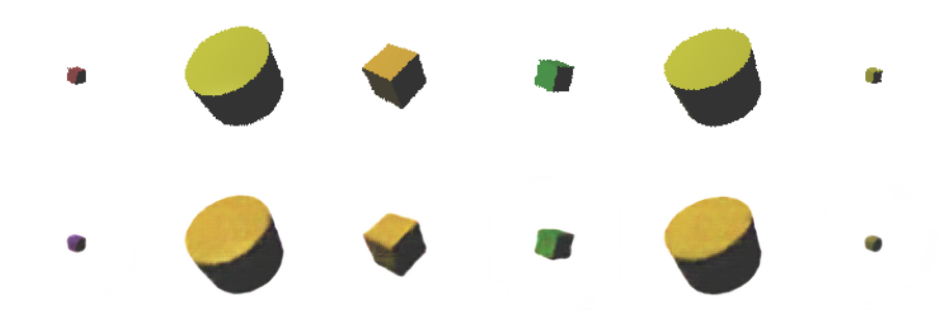

In [84]:
old_model.eval()

with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device)
    x_hat, mu, logvar = old_model(x)

num_images = 6
plt.figure(figsize=(12,4))

for i in range(num_images):
    plt.subplot(2, num_images, i+1)
    plt.imshow(x[i].cpu().permute(1,2,0).numpy())
    plt.axis("off")


    plt.subplot(2, num_images, i+1+num_images)
    plt.imshow(x_hat[i].cpu().permute(1,2,0).numpy())
    plt.axis("off")

plt.show()

In [60]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for x, labels in test_loader:  # ou train_loader
        x = x.to(device)
        x_hat, mu, logvar = model(x)
        z = model.reparameterize(mu, logvar)
        all_mu.append(z.cpu())
        all_labels.append(labels)

# concatenar tudo
all_mu = torch.cat(all_mu, dim=0)
all_labels = torch.cat(all_labels, dim=0)


In [61]:
cube_latents = all_mu[all_labels == 0]
cylinder_latents = all_mu[all_labels == 1]

In [97]:
mean_cube = cube_latents.mean(dim=0)
mean_cylinder = cylinder_latents.mean(dim=0)

print("Mean latent (cube):")
print(mean_cube)

print("\nMean latent (cylinder):")
print(mean_cylinder)

print("\nAverage diff:")
print(np.array(mean_cube) - np.array(mean_cylinder))

mid = cube_latents[0]

mid = 1*(mean_cube) + 1*(mean_cylinder)
mid = mid.unsqueeze(0)
mid = mid.to(device)

Mean latent (cube):
tensor([-0.0561, -0.2253, -0.1989, -0.0788,  0.0480,  0.9199, -0.8701, -0.0505,
         0.0344, -0.0739, -0.1344,  0.1156, -0.1258, -0.3262, -0.1655,  0.0190])

Mean latent (cylinder):
tensor([ 0.0054, -0.3281, -0.6146,  0.0245, -0.1883, -0.7109,  0.2151, -0.1272,
        -0.0473, -0.1190,  0.2193,  0.6341,  0.0637,  0.0880,  0.1410,  0.0133])

Average diff:
[-0.06149818  0.10287592  0.41569492 -0.10327537  0.23629865  1.6308811
 -1.0852057   0.07671009  0.08163741  0.04512592 -0.35363555 -0.518511
 -0.18954143 -0.41421413 -0.30646113  0.00576168]


C:\Users\pyde1\AppData\Local\Temp\ipykernel_5536\372160044.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(np.array(mean_cube) - np.array(mean_cylinder))


In [98]:
old_model.eval()


with torch.no_grad():
    h = old_model.fc_dec(mid)
    h = h.view(mid.size(0), 256, 8, 8)
    generated = old_model.decoder(h)

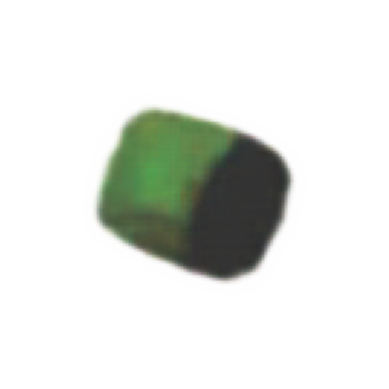

: 

In [ ]:
img = generated[0].cpu().permute(1,2,0).numpy()

plt.imshow(img)
plt.axis("off")
plt.show()

In [70]:
old_model = model  # antes de redefinir